In [22]:
# Setup: Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

plt.style.use("default")
sns.set_theme()

In [23]:
# Data Loading: Load customer features data
df = pd.read_csv("customer_features_v2.csv")

print(df.shape)
df.head()

(97916, 19)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,last_purchase,frequency,recency_days,monetary_value,avg_delivery_time_days,avg_delay_days,late_delivery_rate,unique_products,unique_categories,unique_sellers,avg_review_score,good_review_rate,bad_review_rate,avg_installments
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,2017-05-16 15:05:35,1,519,124.99,8.0,-11.0,0.0,1,1,1,4.0,1.0,0.0,2.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,2018-01-12 20:48:24,1,277,289.00,16.0,-8.0,0.0,1,1,1,5.0,1.0,0.0,8.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,2018-05-19 16:07:45,1,151,139.94,26.0,1.0,1.0,1,1,1,5.0,1.0,0.0,7.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,2018-03-13 16:06:38,1,218,149.94,14.0,-13.0,0.0,1,1,1,5.0,1.0,0.0,1.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,2018-07-29 09:51:30,1,80,230.00,11.0,-6.0,0.0,1,1,1,5.0,1.0,0.0,8.0


In [24]:
# Data Exploration: Display DataFrame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97916 entries, 0 to 97915
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               97916 non-null  object 
 1   customer_unique_id        97916 non-null  object 
 2   customer_zip_code_prefix  97916 non-null  int64  
 3   customer_city             97916 non-null  object 
 4   customer_state            97916 non-null  object 
 5   last_purchase             97916 non-null  object 
 6   frequency                 97916 non-null  int64  
 7   recency_days              97916 non-null  int64  
 8   monetary_value            97916 non-null  float64
 9   avg_delivery_time_days    95829 non-null  float64
 10  avg_delay_days            95829 non-null  float64
 11  late_delivery_rate        97916 non-null  float64
 12  unique_products           97916 non-null  int64  
 13  unique_categories         97916 non-null  int64  
 14  unique

In [25]:
# Data Exploration: Display descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,97916.0,35174.983772,29822.392569,1003.00,11353.75,24422.0,59032.75,99990.0
frequency,97916.0,1.000000,0.000000,1.00,1.00,1.0,1.00,1.0
recency_days,97916.0,289.183351,153.411006,44.00,165.00,270.0,399.00,772.0
monetary_value,97916.0,137.534315,209.483686,0.85,45.90,86.9,149.90,13440.0
avg_delivery_time_days,95829.0,12.052322,9.465505,0.00,6.00,10.0,15.00,208.0
avg_delay_days,95829.0,-11.914567,10.112379,-147.00,-17.00,-12.0,-7.00,188.0
late_delivery_rate,97916.0,0.065168,0.246824,0.00,0.00,0.0,0.00,1.0
unique_products,97916.0,1.037900,0.225802,1.00,1.00,1.0,1.00,8.0
unique_categories,97916.0,0.993454,0.147934,0.00,1.00,1.0,1.00,3.0
unique_sellers,97916.0,1.013583,0.122191,1.00,1.00,1.0,1.00,5.0


In [26]:
# Data Cleaning: Identify missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

,0
avg_delivery_time_days,2087
avg_delay_days,2087


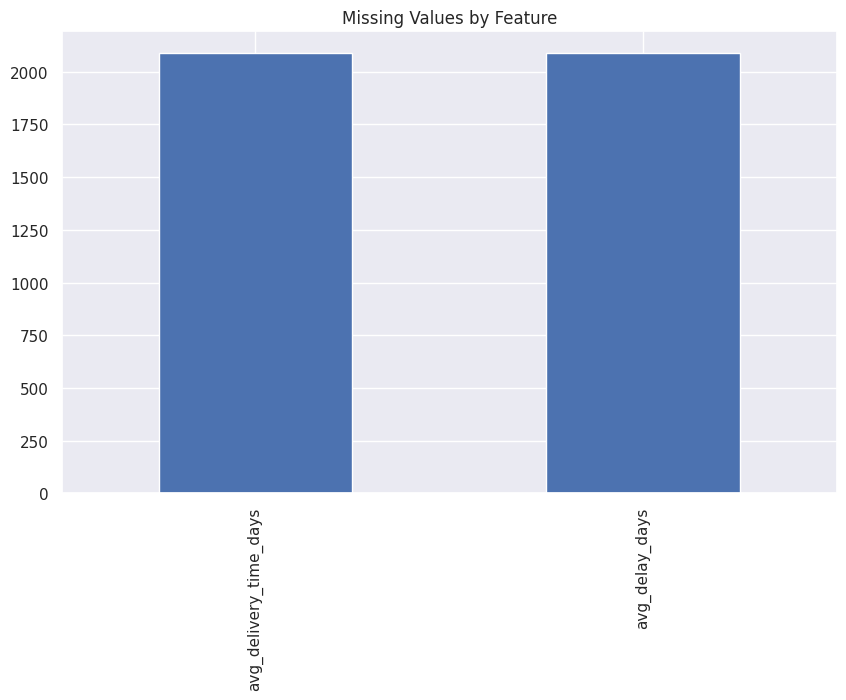

In [27]:
# Data Visualization: Plot missing values
plt.figure(figsize=(10,6))

missing.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.show()

In [28]:
# Data Preparation: Identify numerical columns
num_cols = df.select_dtypes(
    include=np.number
).columns

num_cols

Index(['customer_zip_code_prefix', 'frequency', 'recency_days',
       'monetary_value', 'avg_delivery_time_days', 'avg_delay_days',
       'late_delivery_rate', 'unique_products', 'unique_categories',
       'unique_sellers', 'avg_review_score', 'good_review_rate',
       'bad_review_rate', 'avg_installments'],
      dtype='object')

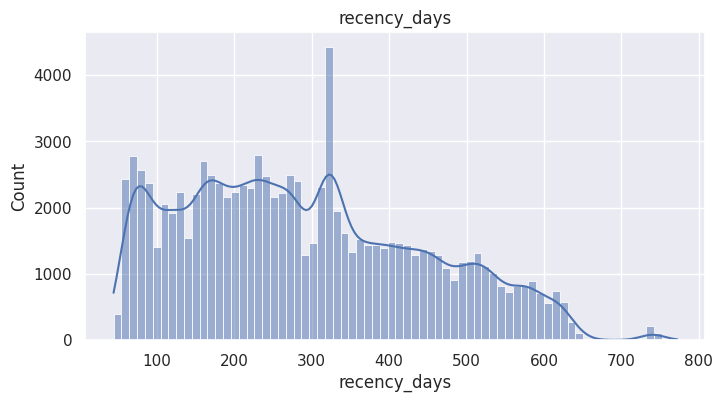

recency_days Skewness: 0.43291618058004555


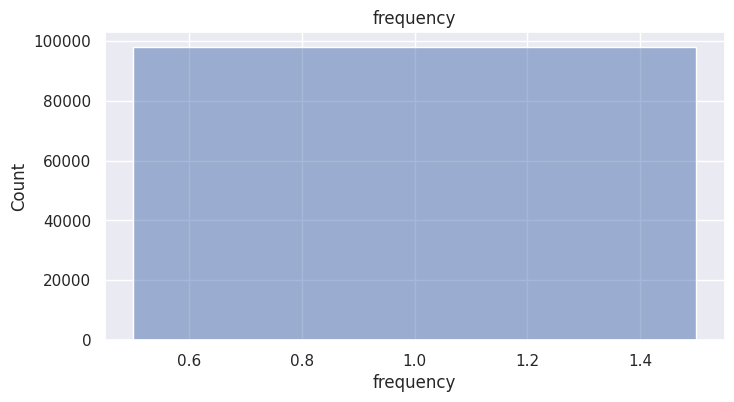

frequency Skewness: nan


/tmp/ipykernel_1039/3844217031.py:26: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(


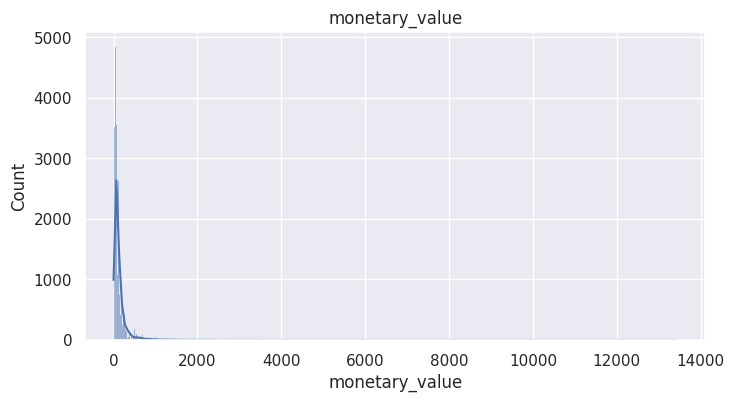

monetary_value Skewness: 9.605399602796908


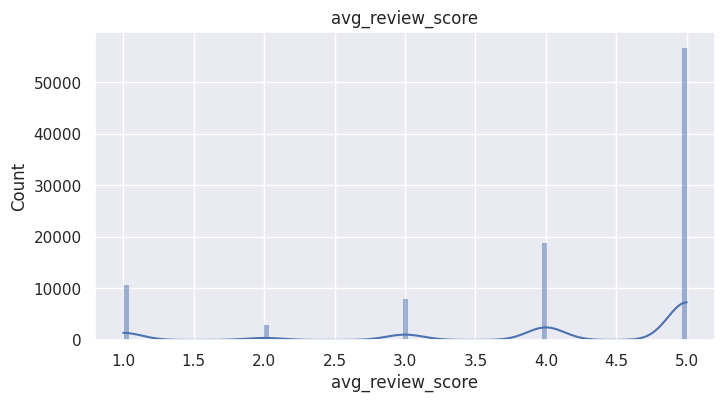

avg_review_score Skewness: -1.3954304512167504


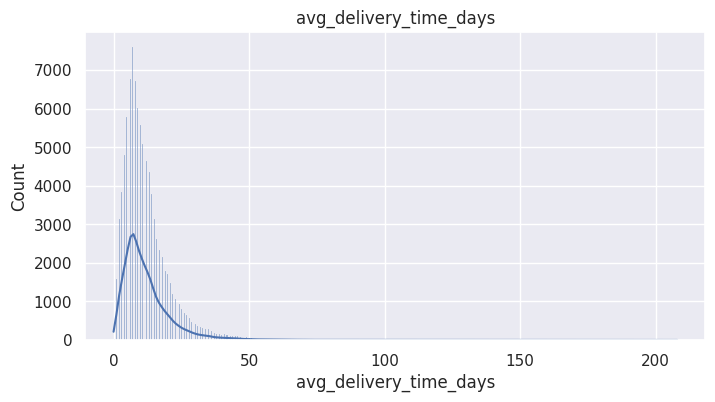

avg_delivery_time_days Skewness: 3.774724275675544


In [29]:
# Data Visualization: Plot distributions and skewness of important features
important_features = [
    "recency_days",
    "frequency",
    "monetary_value",
    "avg_review_score",
    "avg_delivery_time_days"
]

for col in important_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

    print(
        col,
        "Skewness:",
        skew(
            df[col].dropna()
        )
    )

In [30]:
# Data Analysis: Identify outliers for 'monetary_value'
Q1 = df["monetary_value"].quantile(0.25)

Q3 = df["monetary_value"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[
    (df["monetary_value"] < lower)
    |
    (df["monetary_value"] > upper)
]

print(outliers.shape)

(7841, 19)


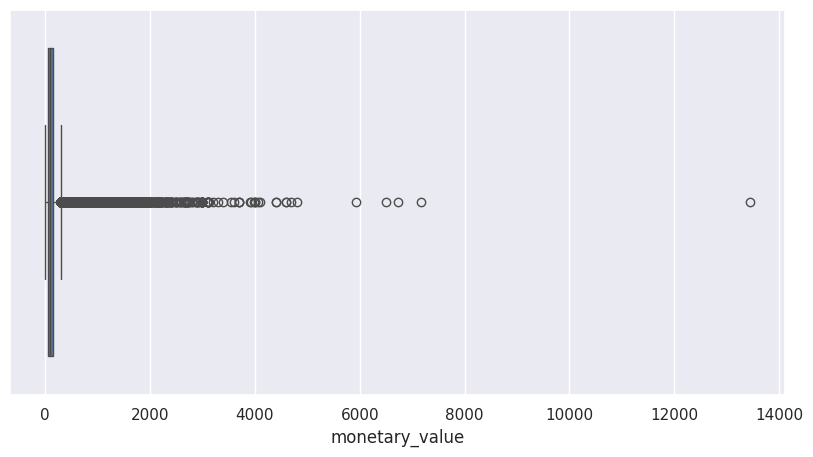

In [31]:
# Data Visualization: Boxplot for 'monetary_value'
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["monetary_value"]
)

plt.show()

In [32]:
# Data Analysis: Calculate feature correlation matrix
corr = df.select_dtypes(
    include=np.number
).corr()

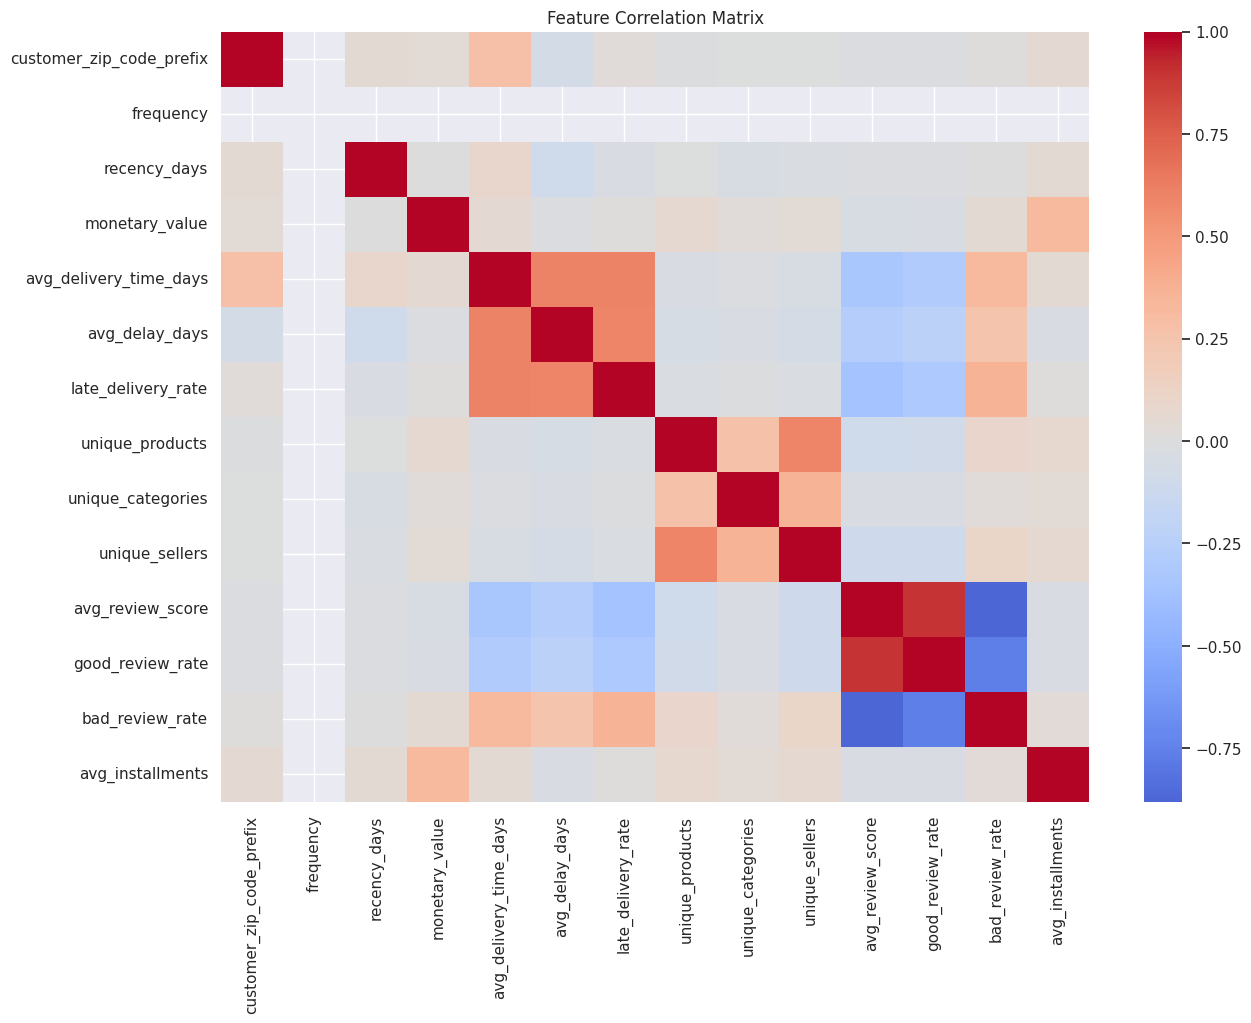

In [33]:
# Data Visualization: Plot feature correlation heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

In [34]:
# Data Analysis: Sort correlations with 'monetary_value'
corr["monetary_value"]\
.sort_values(
    ascending=False
)

,monetary_value
monetary_value,1.000000
avg_installments,0.312754
unique_products,0.062277
avg_delivery_time_days,0.055202
bad_review_rate,0.047702
unique_sellers,0.042038
customer_zip_code_prefix,0.041565
unique_categories,0.024267
late_delivery_rate,0.014943
recency_days,0.002617


In [35]:
# Data Analysis: Analyze top revenue states
state_analysis = (
    df.groupby("customer_state")
      ["monetary_value"]
      .sum()
      .sort_values(
          ascending=False
      )
      .head(10)
)

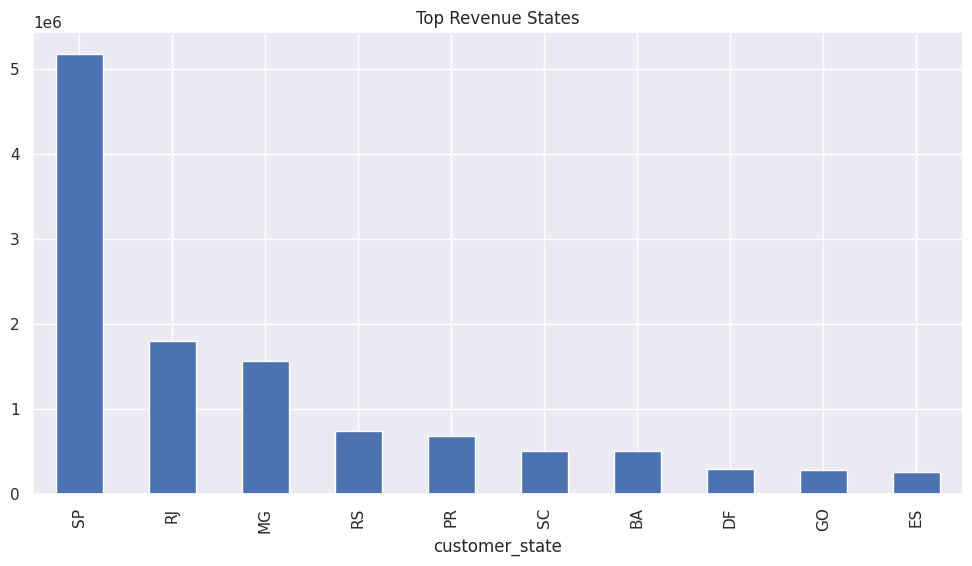

In [36]:
# Data Visualization: Plot top revenue states
plt.figure(figsize=(12,6))

state_analysis.plot(
    kind="bar"
)

plt.title(
    "Top Revenue States"
)

plt.show()

In [37]:
# RFM Modeling: Calculate R, F, and M scores
df["R_score"] = pd.qcut(
    df["recency_days"],
    5,
    labels=[5,4,3,2,1]
)

df["F_score"] = 1 # Assigned directly as frequency has only one unique value (1.0)

df["M_score"] = pd.qcut(
    df["monetary_value"],
    5,
    labels=[1,2,3,4,5]
)

In [38]:
# RFM Modeling: Combine R, F, and M scores into a single RFM string
df["RFM"] = (
    df["R_score"].astype(str)
    +
    df["F_score"].astype(str)
    +
    df["M_score"].astype(str)
)

In [39]:
# RFM Analysis: Check the count of '555' RFM customers
df[
    df["RFM"]=="555"
].shape

(0, 23)